In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
from io import BytesIO

In [16]:
z = zipfile.ZipFile('names.zip')

In [18]:

all_data = []

# Read files
for file in z.namelist():

    # Select only useful yob files
    if file.startswith('names/yob') and file.endswith('.txt'):

        # Extract year
        year = file[9:13]

        # Read file
        df = pd.read_csv(
            BytesIO(z.read(file)),
            names=['Name', 'Gender', 'Count']
        )

        # Add year column
        df['Year'] = int(year)

        # Store dataframe
        all_data.append(df)

# Combine all data
babynames = pd.concat(all_data, ignore_index=True)

# Display first rows
print(babynames.head())

      Name Gender  Count  Year
0    Emily      F  25959  2000
1   Hannah      F  23087  2000
2  Madison      F  19968  2000
3   Ashley      F  18000  2000
4    Sarah      F  17715  2000


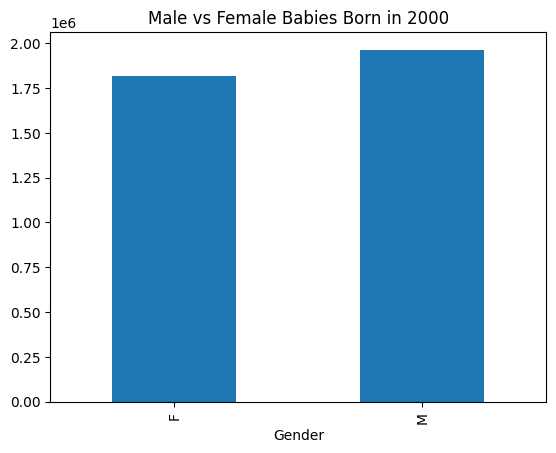

In [21]:
year_data = babynames[babynames['Year'] == 2000]

gender_count = year_data.groupby('Gender')['Count'].sum()

gender_count.plot(kind='bar')

plt.title('Male vs Female Babies Born in 2000')
plt.show()

Gender
F    1816036
M    1964001
Name: Count, dtype: int64


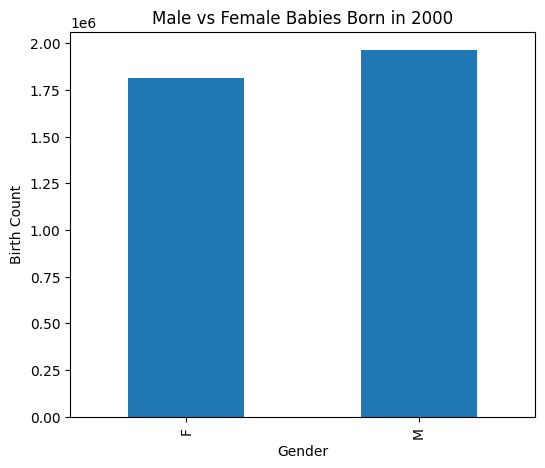

In [23]:
# Select year
year_data = babynames[babynames['Year'] == 2000]

# Group by gender
gender_count = year_data.groupby('Gender')['Count'].sum()

# Print counts
print(gender_count)

# Plot graph
gender_count.plot(
    kind='bar',
    figsize=(6,5)
)

plt.title('Male vs Female Babies Born in 2000')
plt.xlabel('Gender')
plt.ylabel('Birth Count')

plt.show()

In [25]:
# Total counts by name
popular_names = babynames.groupby('Name')['Count'].sum()

# Sort descending
popular_names = popular_names.sort_values(ascending=False)

# Display top 10
print(popular_names.head(10))

Name
James      5274520
John       5204377
Robert     4869849
Michael    4448633
William    4215725
Mary       4156654
David      3689613
Joseph     2680213
Richard    2587082
Charles    2447135
Name: Count, dtype: int64


In [27]:
top100 = popular_names.head(100)

print(top100)

Name
James      5274520
John       5204377
Robert     4869849
Michael    4448633
William    4215725
            ...   
Aaron       618857
Brenda      610597
Frances     600721
Jose        596732
Nicole      596465
Name: Count, Length: 100, dtype: int64


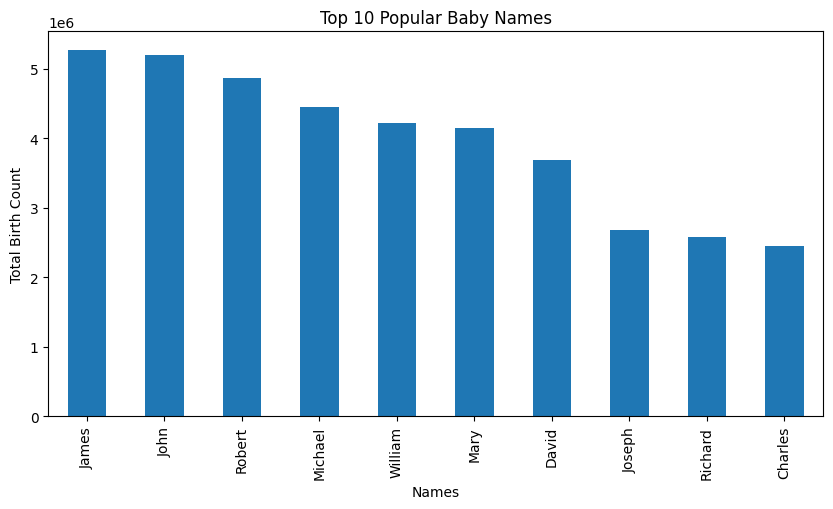

In [29]:
top10 = popular_names.head(10)

top10.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Popular Baby Names')
plt.xlabel('Names')
plt.ylabel('Total Birth Count')

plt.show()

In [31]:
male_names = babynames[babynames['Gender'] == 'M']

top_male = male_names.groupby('Name')['Count'].sum()

top_male = top_male.sort_values(ascending=False)

print(top_male.head(10))

Name
James      5250638
John       5182633
Robert     4849730
Michael    4426753
William    4199696
David      3676654
Joseph     2669490
Richard    2577552
Charles    2434659
Thomas     2358576
Name: Count, dtype: int64


In [33]:
female_names = babynames[babynames['Gender'] == 'F']

top_female = female_names.groupby('Name')['Count'].sum()

top_female = top_female.sort_values(ascending=False)

print(top_female.head(10))

Name
Mary         4141481
Elizabeth    1688757
Patricia     1573623
Jennifer     1471703
Linda        1455143
Barbara      1436695
Margaret     1264774
Susan        1123481
Dorothy      1112231
Sarah        1098498
Name: Count, dtype: int64


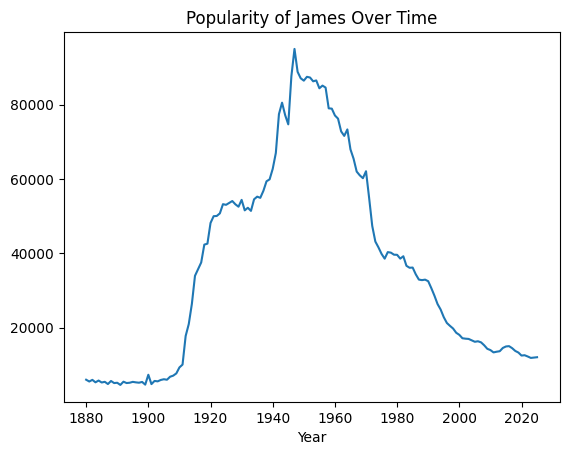

In [35]:
james = babynames[babynames['Name'] == 'James']

james.groupby('Year')['Count'].sum().plot(kind='line')

plt.title('Popularity of James Over Time')

plt.show()